# Customer Segmentation Project

## Objective

The objective of this project is to segment customers based on their purchasing behavior and demographic information using K-Means clustering.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Algorithm

K-Means Clustering

In [1]:
!pip install pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Loading the Dataset

In this step, the customer dataset is uploaded and loaded into the notebook for analysis.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (2).csv


In [4]:
import pandas as pd

df = pd.read_csv(next(iter(uploaded)))

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


## Understanding the Dataset

Let's examine the structure of the dataset, check the data types, identify missing values, and view statistical summaries.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [9]:
df.shape

(1000, 5)

## Data Cleaning

The dataset is checked for missing values and duplicates before performing customer segmentation.

In [10]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [11]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Exploratory Data Analysis (EDA)

Visualize customer demographics and purchasing behavior to better understand the dataset.

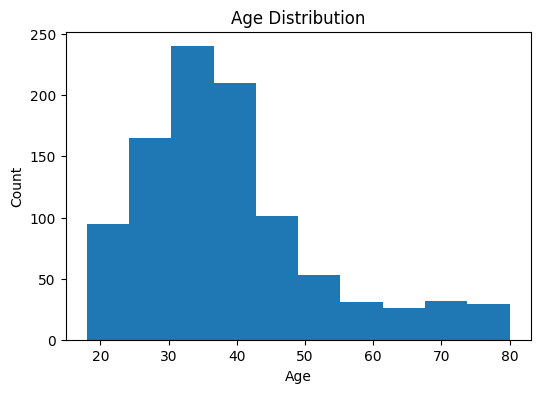

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

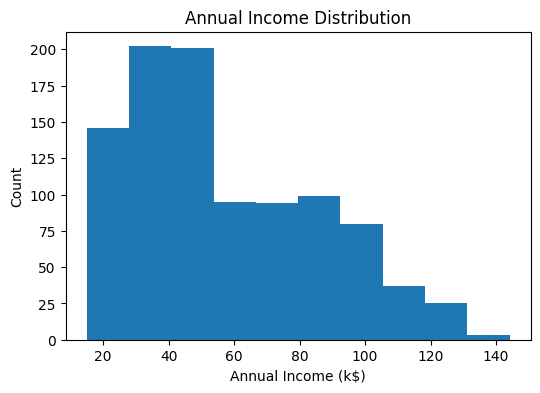

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df['Annual Income (k$)'], bins=10)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")
plt.show()

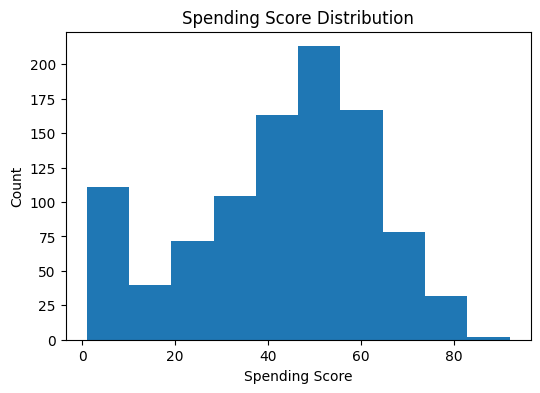

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['Spending Score (1-100)'], bins=10)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

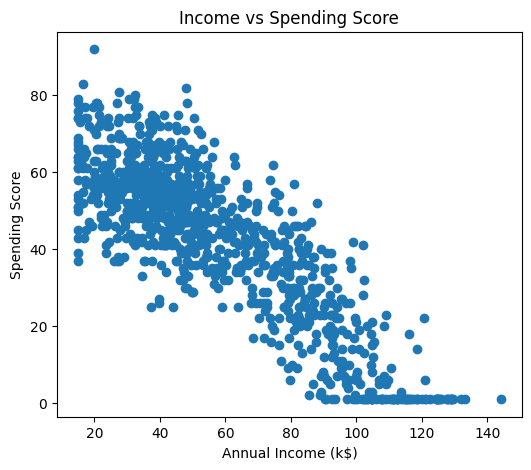

In [15]:
plt.figure(figsize=(6,5))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

## Selecting Features

Annual Income and Spending Score are selected because they provide meaningful information for customer segmentation.

In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


df = df.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

## Feature Scaling

Standardization is applied so both features contribute equally to the clustering algorithm.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Finding the Optimal Number of Clusters

The Elbow Method helps determine the most suitable number of clusters for K-Means.

In [18]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

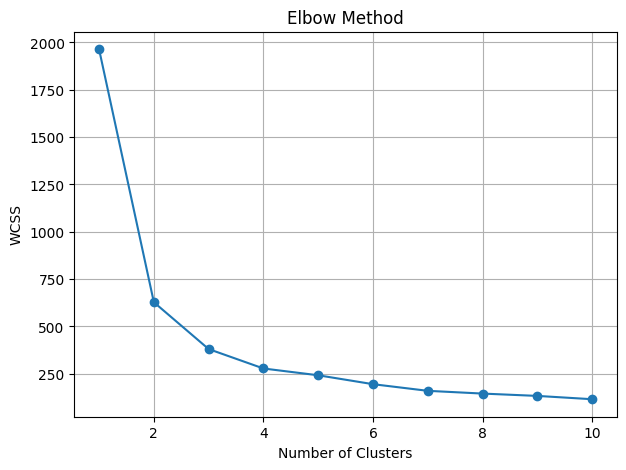

In [19]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

The elbow point appears around 5 clusters, so K-Means will be trained using 5 clusters.

## Building the K-Means Clustering Model

In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,2
1,1001,M,34.0,48.4,37.0,4
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,2


## Visualizing Customer Segments

Each color represents a different customer segment identified by the K-Means algorithm.

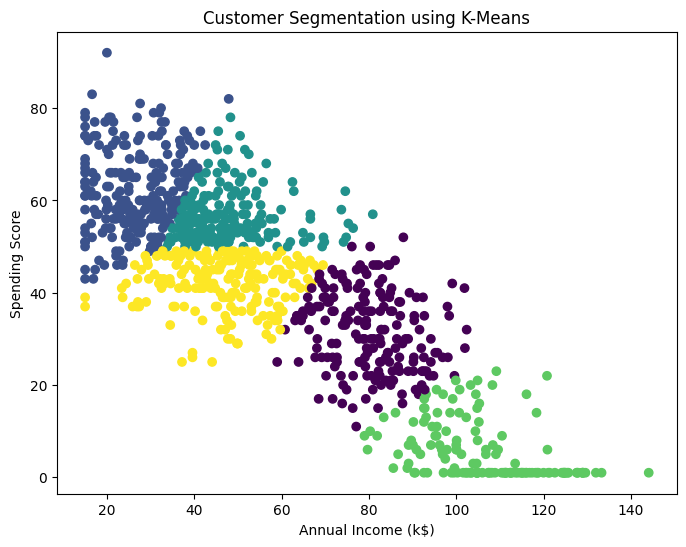

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

## Gender Distribution

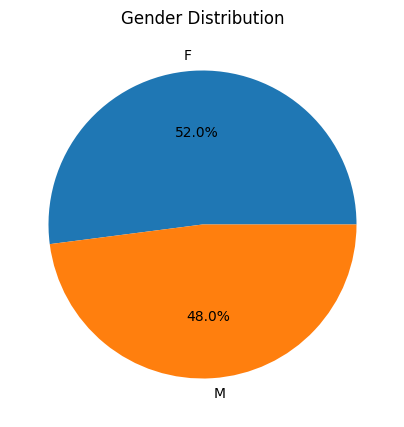

In [23]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%')

plt.title("Gender Distribution")
plt.show()

## Cluster Centers

In [24]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(
    centers,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

cluster_centers

,Annual Income (k$),Spending Score (1-100)
0,80.541753,31.587629
1,26.924280,61.954733
2,47.584184,56.668367
3,106.266197,5.753521
4,46.912560,42.173913


## Cluster Summary

Analyze the average characteristics of customers in each cluster.

In [25]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,1471.690722,44.855670,80.541753,31.587629
1,1458.995868,26.855372,26.916529,62.012397
2,1423.459184,34.520408,47.584184,56.668367
3,1811.394366,64.584507,106.266197,5.753521
4,1435.086538,34.225962,46.825481,42.201923


In [26]:
df.groupby("Cluster").size()

,0
Cluster,
0,194
1,242
2,196
3,142
4,208


## Business Insights

- Cluster 0 represents customers with moderate income and moderate spending.
- Cluster 1 represents customers with high income and high spending, making them premium customers.
- Cluster 2 contains customers with low income and low spending.
- Cluster 3 includes customers with high income but lower spending, who can be targeted through personalized offers.
- Cluster 4 includes customers with lower income but relatively high spending, who may respond well to loyalty programs.

## Conclusion

The K-Means clustering algorithm successfully segmented customers into five distinct groups based on Annual Income and Spending Score.

The segmentation provides valuable insights into customer purchasing behavior and supports targeted marketing strategies, customer retention, and personalized promotional campaigns.